# Anomaly Detection in Transactions — 01 Exploratory Data Analysis

**Unsupervised anomaly detection** on credit-card transactions. The dataset is the ULB credit-card fraud dataset: 28 anonymised PCA features (`V1`–`V28`) plus `Time` and `Amount`, and a `Class` label (1 = fraud, 0 = genuine).

The detectors in notebook 03 are trained **without labels** — they flag transactions that look statistically unusual. We use `Class` here in EDA, and later for evaluation only, to understand what fraud looks like.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import utils

df = utils.load_data()
print('shape:', df.shape)
df.head()

shape: (20492, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,81870.0,0.520825,-1.879553,-0.282574,-0.161326,-1.411747,-0.719947,0.217149,-0.249617,-1.055603,...,-0.129752,-0.797538,-0.364506,0.592375,0.203844,1.017832,-0.156043,0.063420,434.96,0
1,160985.0,-10.038993,8.102170,-5.054436,-2.762653,-2.189736,-1.235578,-0.275387,1.597294,6.786402,...,-1.482515,-1.196301,0.431425,-0.549693,1.369295,0.096761,1.838059,0.385465,13.48,0
2,162054.0,2.107499,0.016518,-1.592458,0.178811,0.411275,-0.763080,0.221481,-0.313812,0.543366,...,0.223297,0.795815,-0.006808,0.520501,0.342356,-0.127009,-0.022193,-0.053948,0.99,0
3,121981.0,1.878563,0.020785,-1.621113,2.908813,2.507847,4.709442,-0.830626,1.136154,-0.395755,...,0.079998,0.404327,0.121098,0.707538,0.140100,0.155684,0.016375,-0.053892,0.00,0
4,60373.0,1.261370,0.275392,0.035706,0.417287,0.009871,-0.357571,-0.039411,-0.005357,-0.160482,...,-0.282513,-0.854857,0.033234,-0.400760,0.273368,0.120034,-0.028675,0.013423,1.98,0


## 1. Class distribution (severe imbalance)

Fraud is rare — this is what makes it an *anomaly* problem rather than ordinary classification.

Class
0    20000
1      492
Name: count, dtype: int64
fraud rate: 2.4009%


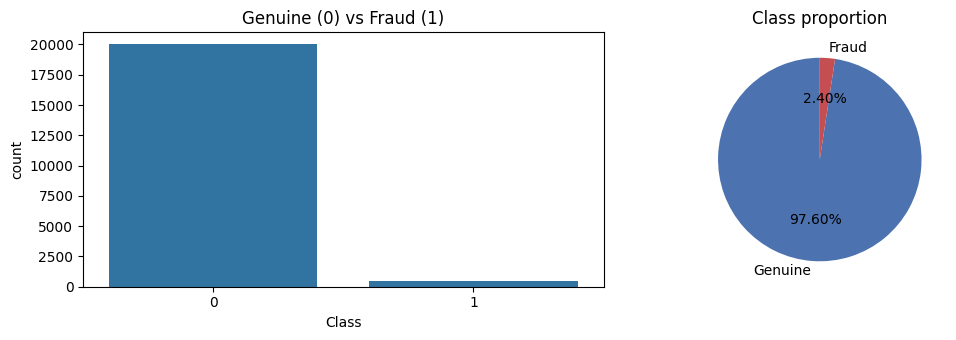

In [2]:
counts = df['Class'].value_counts()
print(counts)
print(f'fraud rate: {100*df.Class.mean():.4f}%')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.countplot(x='Class', data=df, ax=ax[0]); ax[0].set_title('Genuine (0) vs Fraud (1)')
ax[1].pie(counts, labels=['Genuine','Fraud'], autopct='%1.2f%%', startangle=90, colors=['#4c72b0','#c44e52'])
ax[1].set_title('Class proportion'); plt.tight_layout(); plt.show()

## 2. Transaction Amount: fraud vs genuine

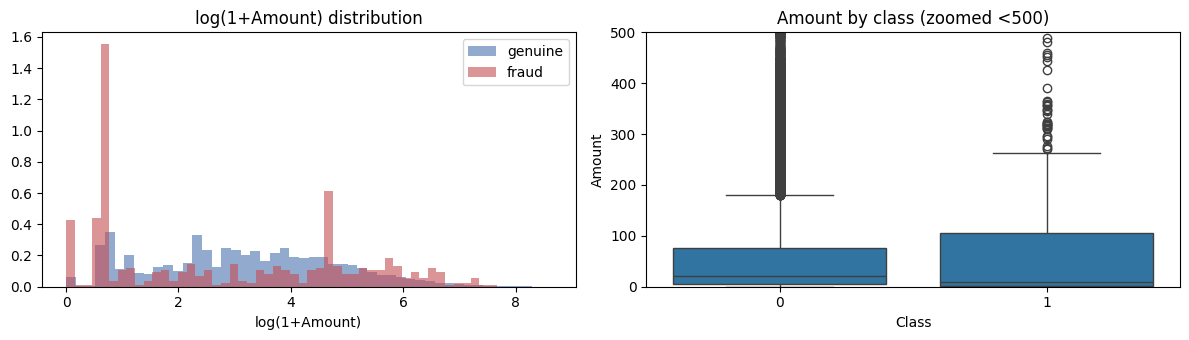

             mean    50%      max
Class                            
0       86.323937  22.00  5627.06
1      122.211321   9.25  2125.87


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for cls, lab, c in [(0,'genuine','#4c72b0'), (1,'fraud','#c44e52')]:
    ax[0].hist(np.log1p(df[df.Class==cls].Amount), bins=50, alpha=0.6, label=lab, color=c, density=True)
ax[0].set_title('log(1+Amount) distribution'); ax[0].set_xlabel('log(1+Amount)'); ax[0].legend()
sns.boxplot(x='Class', y='Amount', data=df, ax=ax[1]); ax[1].set_ylim(0, 500); ax[1].set_title('Amount by class (zoomed <500)')
plt.tight_layout(); plt.show()
print(df.groupby('Class')['Amount'].describe()[['mean','50%','max']])

## 3. Most discriminative PCA features

Some PCA components separate fraud strongly. We rank features by the absolute difference in class means and look at the top ones.

Top 6 features by |mean difference| between classes:
Time      14412.138289
Amount       35.887384
V3            7.033415
V14           6.981816
V17           6.675298
V12           6.282032
dtype: float64


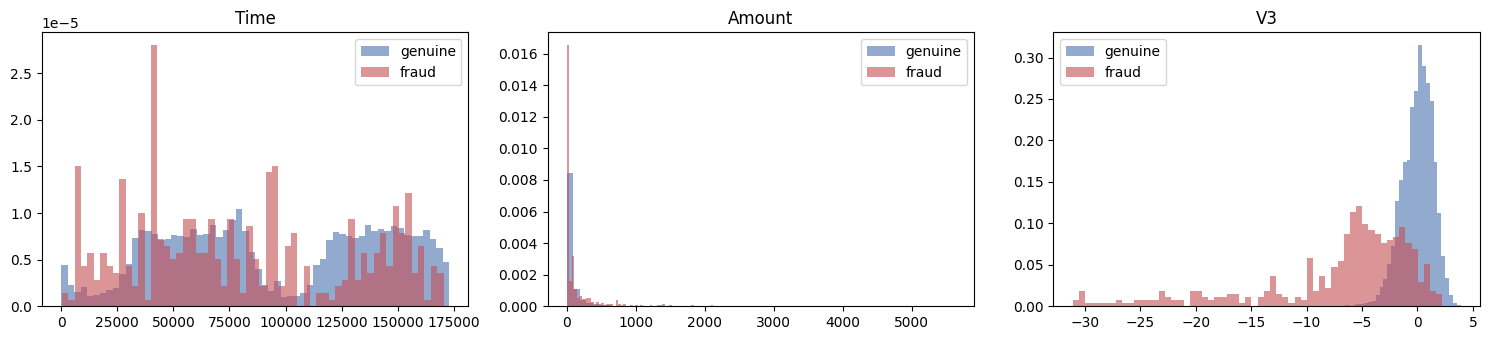

In [4]:
feat_cols = [c for c in df.columns if c != 'Class']
mean_diff = (df[df.Class==1][feat_cols].mean() - df[df.Class==0][feat_cols].mean()).abs().sort_values(ascending=False)
print('Top 6 features by |mean difference| between classes:')
print(mean_diff.head(6))
top = mean_diff.head(3).index.tolist()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for i, f in enumerate(top):
    for cls, lab, c in [(0,'genuine','#4c72b0'), (1,'fraud','#c44e52')]:
        ax[i].hist(df[df.Class==cls][f], bins=60, alpha=0.6, label=lab, color=c, density=True)
    ax[i].set_title(f'{f}'); ax[i].legend()
plt.tight_layout(); plt.show()

## 4. Correlation of each feature with the fraud label

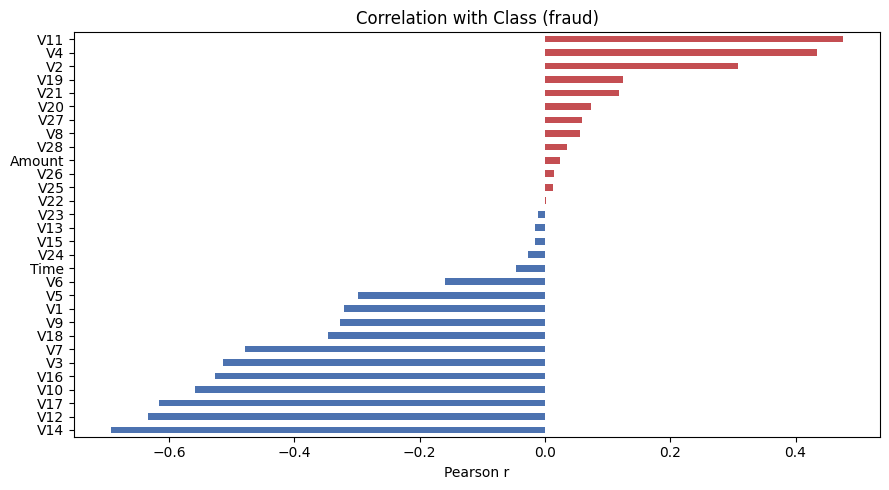

In [5]:
corr = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
corr.plot(kind='barh', ax=ax, color=np.where(corr<0,'#4c72b0','#c44e52'))
ax.set_title('Correlation with Class (fraud)'); ax.set_xlabel('Pearson r'); plt.tight_layout(); plt.show()

## 5. Summary of findings

- The subsample holds **20,492 transactions with 492 frauds — a 2.40% fraud rate** (all frauds from the source kept; genuine transactions sub-sampled).
- Fraud has a **lower median amount (9.25 vs 22.00)** than genuine spend, though a higher mean — fraud is not simply 'large transactions'.
- By correlation with the fraud label, the most discriminative PCA features are **V14 (r=0.69), V12 (0.63), V17 (0.62), V10 (0.56), V16 (0.53)** — anomaly detectors should latch onto this structure.
- Next: notebook **02** checks data quality and standardises features for the detectors.